In [56]:
# BUSINESS SALES PERFORMANCE ANALYSIS

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
#loading dataset
df = pd.read_csv("Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [40]:
#info checking
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [41]:
#checking missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [42]:
#removing missing values
df.dropna(inplace=True)

In [43]:
#removing duplicate values
df.drop_duplicates(inplace=True)

In [44]:
#fixing date formats
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=False)

In [45]:
#removing negative values
df = df[df['Sales'] > 0]

In [46]:
#creating columns for analysis
#Profit Margin
df['Profit Margin'] = df['Profit'] / df['Sales']

#Month column
df['Month'] = df['Order Date'].dt.month

#Year column
df['Year'] = df['Order Date'].dt.year


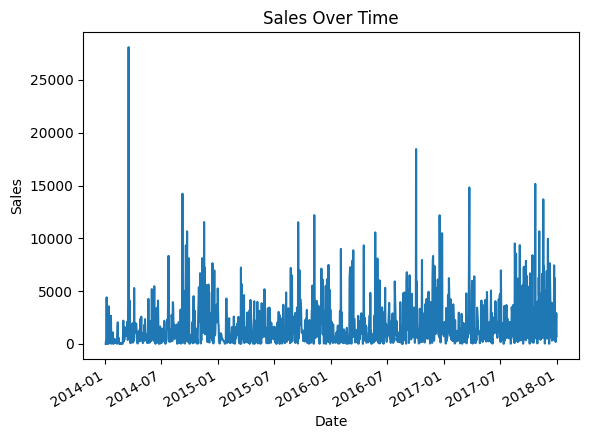

In [47]:
#line chart (Sales over Time)
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure()
#sales over time analysis
sales_trend.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
#insight:
#Sales show an overall increasing trend over time with noticeable fluctuations, indicating seasonal demand patterns.

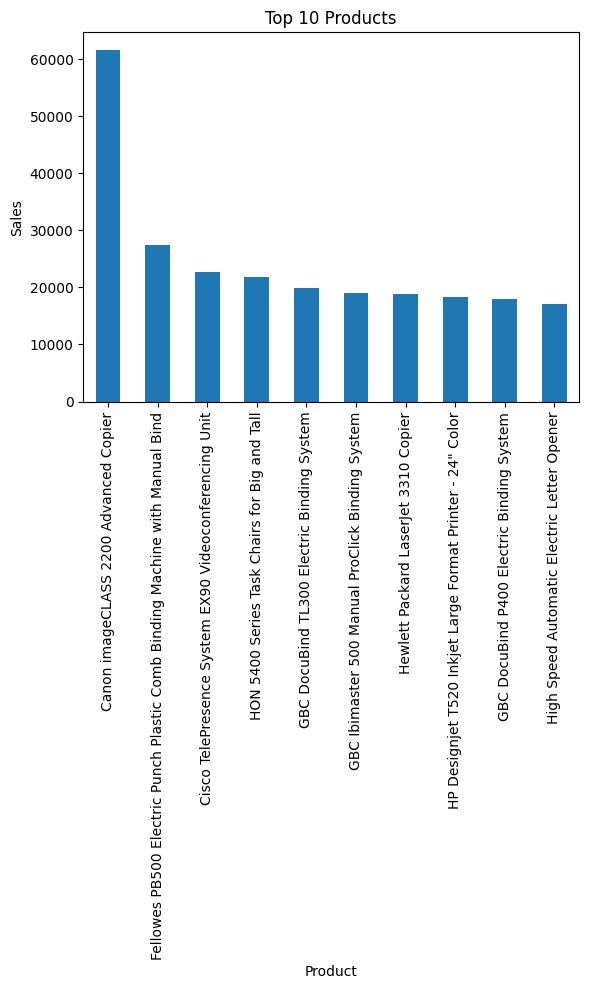

In [48]:
#bar chart (top 10 products)
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
#top sold products analysis
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()
#insight
# small number of products contribute significantly to total revenue, indicating high dependency on top-performing products.

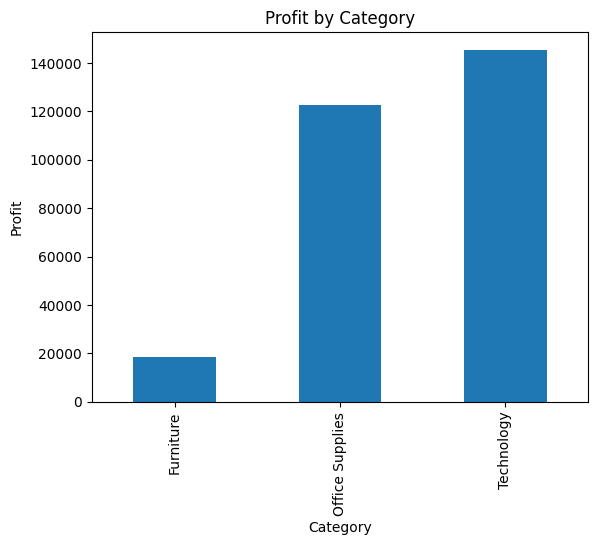

In [49]:
#bar chart (category wise profit)
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure()
#category wise profit analysis
category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()
#insight
#Technology category generates the highest profit, while other categories show lower or inconsistent profitability.

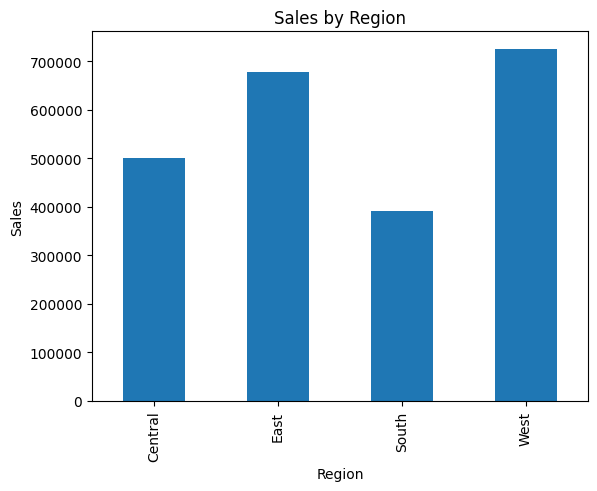

In [50]:
#bar chart (region wise sales)
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
#region wise sales analysis
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()
#insight
#Certain regions contribute more to total sales, highlighting geographic performance differences and potential market opportunities.

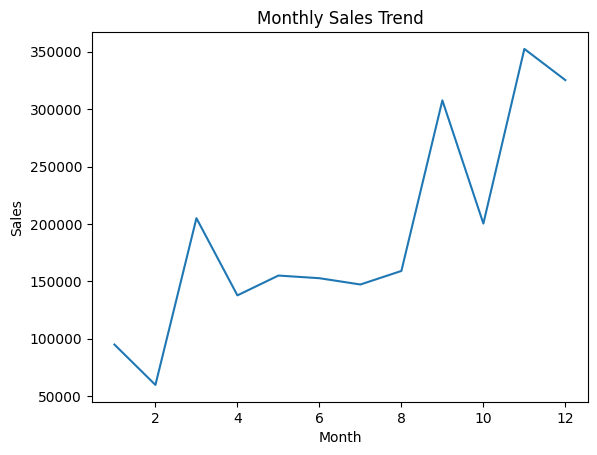

In [55]:
#line chart (monthly sales trend)
monthly_sales = df.groupby('Month')['Sales'].sum().sort_index()

plt.figure()
#monthly sales trend analysis
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()
#insight
#Sales vary across months, with peak periods indicating strong seasonal demand patterns.

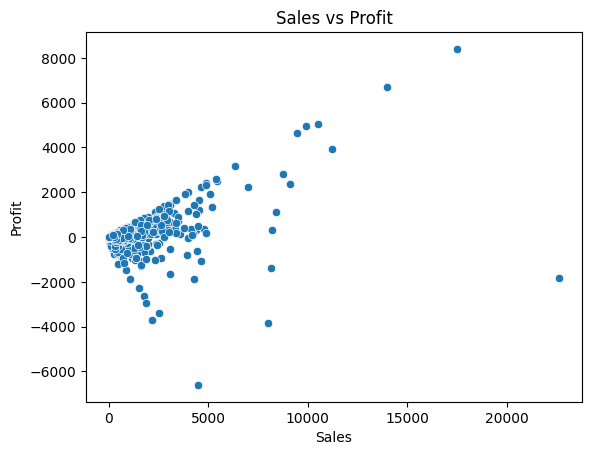

In [52]:
#Scatter plot (Sales VS profits)
plt.figure()
#sales VS profits analysis
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()
#insight
#While higher sales often lead to higher profit, several transactions show high sales but low or negative profit,
#indicating possible discount or cost issues.

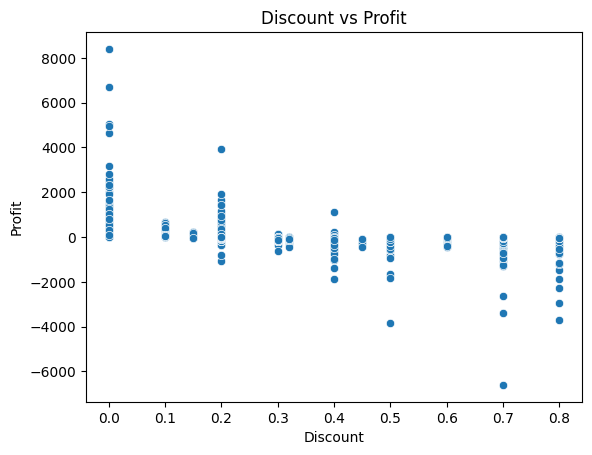

In [53]:
#scatter plot(discount VS profit)
plt.figure()
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

# Insight:
# Higher discounts often lead to lower or negative profit, indicating pricing inefficiencies.

In [54]:
# FINAL CONCLUSION:
# The analysis reveals that while the business generates strong revenue,
# profitability varies across categories and regions.
# Strategic focus on high-performing products, optimized pricing,
# and better regional planning can improve overall business performance.